## tuning, final evaluation, saving and loading


In [1]:
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.db import get_engine, fetch_table
from src.config import FEATURE_COLS_NO_WIFI
from src.features import make_features

print("Project root:", project_root)

Project root: d:\OMEN-16\ML-Projects\airline-satisfaction-ml


In [2]:
engine = get_engine()
df = fetch_table(engine)

X = make_features(df)
y = (df["satisfaction"] == "Satisfied").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_no_wifi = X_train[FEATURE_COLS_NO_WIFI]

print("X_train:", X_train.shape)
print("X_train_no_wifi:", X_train_no_wifi.shape)
print("Share satisfied in y_train:", round(y_train.mean(), 4))

X_train: (103904, 18)
X_train_no_wifi: (103904, 17)
Share satisfied in y_train: 0.4345


## Here are three models to tune

In [3]:
# preprocessing  (all three models are tree-based)
tree_prep = ColumnTransformer(
    [
        ("class_order", OrdinalEncoder(categories=[["Economy", "Economy Plus", "Business"]]), ["travel_class"]),
        ("two_labels", OrdinalEncoder(), ["customer_type", "type_of_travel"]),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
tree_prep.set_output(transform="pandas")

lgbm = make_pipeline(clone(tree_prep), LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
xgb = make_pipeline(clone(tree_prep), XGBClassifier(random_state=42, n_jobs=-1))
forest = make_pipeline(clone(tree_prep), RandomForestClassifier(random_state=42, n_jobs=-1))

base_models = {
    "LightGBM": lgbm,
    "XGBoost": xgb,
    "Random Forest": forest,
}

print(list(base_models))

['LightGBM', 'XGBoost', 'Random Forest']


In [4]:
default_wifi = pd.read_csv("../reports/model_comparison_with_wifi.csv", index_col=0)
default_no_wifi = pd.read_csv("../reports/model_comparison_without_wifi.csv", index_col=0)

names = ["LightGBM", "XGBoost", "Random Forest"]

print("Default settings, with wifi:")
print(default_wifi.loc[names, ["accuracy", "f1", "roc_auc", "gap"]])
print()
print("Default settings, without wifi:")
print(default_no_wifi.loc[names, ["accuracy", "f1", "roc_auc", "gap"]])

Default settings, with wifi:
               accuracy     f1  roc_auc   gap
LightGBM          96.30  95.66    99.45  0.24
XGBoost           96.22  95.58    99.46  1.21
Random Forest     96.22  95.57    99.34  3.78

Default settings, without wifi:
               accuracy     f1  roc_auc   gap
LightGBM          94.16  93.17    98.56  0.35
XGBoost           94.16  93.16    98.56  1.87
Random Forest     94.12  93.12    98.43  5.88


In [5]:
# the same 5 folds as Step 10
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# here these are settings to try, the pipeline step name comes first, then two underscores
spaces = {
    "LightGBM": {
        "lgbmclassifier__n_estimators": [100, 200, 300, 400],
        "lgbmclassifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "lgbmclassifier__num_leaves": [15, 31, 63, 127],
        "lgbmclassifier__min_child_samples": [10, 20, 40],
        "lgbmclassifier__colsample_bytree": [0.6, 0.8, 1.0],
    },
    "XGBoost": {
        "xgbclassifier__n_estimators": [100, 200, 300, 400],
        "xgbclassifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "xgbclassifier__max_depth": [4, 6, 8, 10],
        "xgbclassifier__min_child_weight": [1, 3, 5],
        "xgbclassifier__colsample_bytree": [0.6, 0.8, 1.0],
    },
    "Random Forest": {
        "randomforestclassifier__n_estimators": [100, 200],
        "randomforestclassifier__max_depth": [10, 15, 20, 30],
        "randomforestclassifier__min_samples_leaf": [1, 3, 5, 10],
        "randomforestclassifier__max_features": ["sqrt", 0.5],
    },
}

# these are the random combinations to try for each model
tries = {"LightGBM": 12, "XGBoost": 12, "Random Forest": 8}

for name in spaces:
    combos = 1
    for values in spaces[name].values():
        combos = combos * len(values)
    print(name.ljust(15), combos, "possible combinations, we try", tries[name])

LightGBM        576 possible combinations, we try 12
XGBoost         576 possible combinations, we try 12
Random Forest   64 possible combinations, we try 8


#### Running the searches with wifi

In [6]:
searches = {}

for name in base_models:
    start = time.time()

    search = RandomizedSearchCV(base_models[name], spaces[name], n_iter=tries[name],
                                scoring="f1", cv=cv, random_state=42)
    search.fit(X_train, y_train)

    searches[name] = search
    print(name.ljust(15), round(time.time() - start), "seconds | best F1:", round(search.best_score_ * 100, 2))

LightGBM        81 seconds | best F1: 95.93
XGBoost         55 seconds | best F1: 95.77
Random Forest   46 seconds | best F1: 95.66


In [7]:
for name in searches:
    scores = searches[name].cv_results_["mean_test_score"] * 100

    print(name)
    print("  F1 of the", len(scores), "combinations: worst", round(scores.min(), 2),
          "| middle", round(np.median(scores), 2), "| best", round(scores.max(), 2))
    print("  best settings:", searches[name].best_params_)
    print()

LightGBM
  F1 of the 12 combinations: worst 93.58 | middle 95.7 | best 95.93
  best settings: {'lgbmclassifier__num_leaves': 63, 'lgbmclassifier__n_estimators': 300, 'lgbmclassifier__min_child_samples': 40, 'lgbmclassifier__learning_rate': 0.03, 'lgbmclassifier__colsample_bytree': 0.8}

XGBoost
  F1 of the 12 combinations: worst 93.78 | middle 95.62 | best 95.77
  best settings: {'xgbclassifier__n_estimators': 300, 'xgbclassifier__min_child_weight': 3, 'xgbclassifier__max_depth': 10, 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__colsample_bytree': 0.8}

Random Forest
  F1 of the 8 combinations: worst 93.72 | middle 95.29 | best 95.66
  best settings: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_leaf': 3, 'randomforestclassifier__max_features': 0.5, 'randomforestclassifier__max_depth': 30}



In [8]:
# score the three tuned models the same way as Step 10, so the numbers can be compared
tuned = {}

for name in searches:
    scores = cross_validate(searches[name].best_estimator_, X_train, y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
    tuned[name] = pd.DataFrame(scores).mean()

tuned = pd.DataFrame(tuned).T

compare = pd.DataFrame({
    "f1 default": default_wifi.loc[names, "f1"],
    "f1 tuned": tuned["test_f1"] * 100,
    "accuracy tuned": tuned["test_accuracy"] * 100,
    "roc_auc tuned": tuned["test_roc_auc"] * 100,
    "gap default": default_wifi.loc[names, "gap"],
    "gap tuned": (tuned["train_accuracy"] - tuned["test_accuracy"]) * 100,
})
compare["f1 change"] = compare["f1 tuned"] - compare["f1 default"]

compare.round(2)

,f1 default,f1 tuned,accuracy tuned,roc_auc tuned,gap default,gap tuned,f1 change
LightGBM,95.66,95.93,96.53,99.51,0.24,0.45,0.27
XGBoost,95.58,95.77,96.39,99.48,1.21,1.08,0.19
Random Forest,95.57,95.66,96.29,99.41,3.78,2.51,0.09


#### Running the search without wifi

In [9]:
searches_no_wifi = {}

for name in base_models:
    start = time.time()

    search = RandomizedSearchCV(base_models[name], spaces[name], n_iter=tries[name],
                                scoring="f1", cv=cv, random_state=42)
    search.fit(X_train_no_wifi, y_train)

    searches_no_wifi[name] = search
    print(name.ljust(15), round(time.time() - start), "seconds | best F1:", round(search.best_score_ * 100, 2))

LightGBM        77 seconds | best F1: 93.54
XGBoost         50 seconds | best F1: 93.5
Random Forest   35 seconds | best F1: 93.35


In [10]:
for name in searches_no_wifi:
    scores = searches_no_wifi[name].cv_results_["mean_test_score"] * 100

    print(name)
    print("  F1 of the", len(scores), "combinations: worst", round(scores.min(), 2),
          "| middle", round(np.median(scores), 2), "| best", round(scores.max(), 2))
    print("  best settings:", searches_no_wifi[name].best_params_)
    print()

LightGBM
  F1 of the 12 combinations: worst 90.86 | middle 93.34 | best 93.54
  best settings: {'lgbmclassifier__num_leaves': 127, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__min_child_samples': 20, 'lgbmclassifier__learning_rate': 0.05, 'lgbmclassifier__colsample_bytree': 0.8}

XGBoost
  F1 of the 12 combinations: worst 91.77 | middle 93.26 | best 93.5
  best settings: {'xgbclassifier__n_estimators': 300, 'xgbclassifier__min_child_weight': 3, 'xgbclassifier__max_depth': 10, 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__colsample_bytree': 0.8}

Random Forest
  F1 of the 8 combinations: worst 91.77 | middle 92.95 | best 93.35
  best settings: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_leaf': 3, 'randomforestclassifier__max_features': 0.5, 'randomforestclassifier__max_depth': 30}



In [11]:
tuned_nw = {}

for name in searches_no_wifi:
    scores = cross_validate(searches_no_wifi[name].best_estimator_, X_train_no_wifi, y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
    tuned_nw[name] = pd.DataFrame(scores).mean()

tuned_nw = pd.DataFrame(tuned_nw).T

compare_nw = pd.DataFrame({
    "f1 default": default_no_wifi.loc[names, "f1"],
    "f1 tuned": tuned_nw["test_f1"] * 100,
    "accuracy tuned": tuned_nw["test_accuracy"] * 100,
    "roc_auc tuned": tuned_nw["test_roc_auc"] * 100,
    "gap default": default_no_wifi.loc[names, "gap"],
    "gap tuned": (tuned_nw["train_accuracy"] - tuned_nw["test_accuracy"]) * 100,
})
compare_nw["f1 change"] = compare_nw["f1 tuned"] - compare_nw["f1 default"]

compare_nw.round(2)

,f1 default,f1 tuned,accuracy tuned,roc_auc tuned,gap default,gap tuned,f1 change
LightGBM,93.17,93.54,94.49,98.67,0.35,0.68,0.37
XGBoost,93.16,93.50,94.46,98.67,1.87,2.05,0.34
Random Forest,93.12,93.35,94.33,98.51,5.88,3.49,0.23


#### Before and After charts

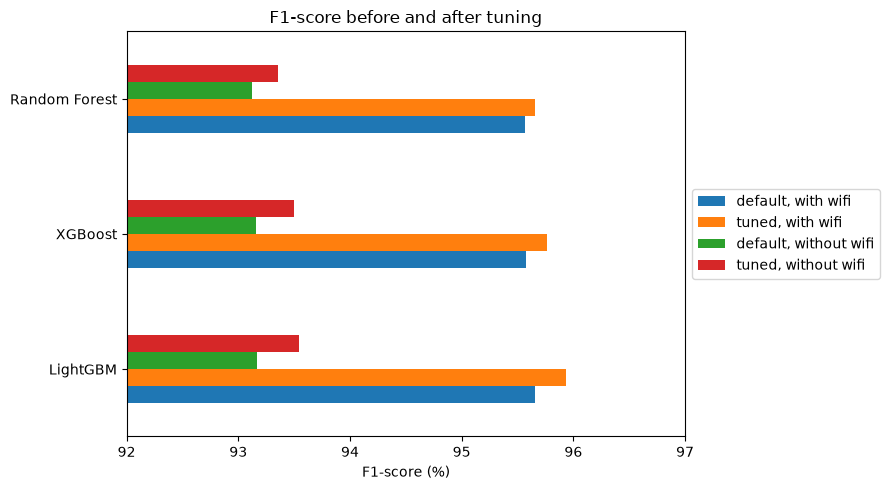

In [12]:
chart = pd.DataFrame({
    "default, with wifi": compare["f1 default"],
    "tuned, with wifi": compare["f1 tuned"],
    "default, without wifi": compare_nw["f1 default"],
    "tuned, without wifi": compare_nw["f1 tuned"],
})

chart.plot(kind="barh", figsize=(9, 5))

plt.title("F1-score before and after tuning")
plt.xlabel("F1-score (%)")
plt.xlim(92, 97)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("../reports/figures/25_tuning_f1.png", dpi=120, bbox_inches="tight")
plt.show()

observation:
- Here for each model, the tuned bar is a little longer than the default bar, in both the with-wifi and the without-wifi pair. LightGBM has the longest bars.

#### Choosing the best model

In [13]:
best_name = compare["f1 tuned"].idxmax()
best_name_no_wifi = compare_nw["f1 tuned"].idxmax()

best_model = searches[best_name].best_estimator_
best_model_no_wifi = searches_no_wifi[best_name_no_wifi].best_estimator_

print("Best model with wifi   :", best_name, "| F1", round(compare.loc[best_name, "f1 tuned"], 2))
print("Best model without wifi:", best_name_no_wifi, "| F1", round(compare_nw.loc[best_name_no_wifi, "f1 tuned"], 2))

Best model with wifi   : LightGBM | F1 95.93
Best model without wifi: LightGBM | F1 93.54


In [14]:
best_settings = {"with_wifi": {}, "without_wifi": {}}

for name in searches:
    best_settings["with_wifi"][name] = searches[name].best_params_
    best_settings["without_wifi"][name] = searches_no_wifi[name].best_params_

with open("../models/best_settings.json", "w") as file:
    json.dump(best_settings, file, indent=2)

compare.round(2).to_csv("../reports/tuning_with_wifi.csv")
compare_nw.round(2).to_csv("../reports/tuning_without_wifi.csv")

print("Saved the best settings and two tuning tables")

Saved the best settings and two tuning tables


In [15]:
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve

sns.set_theme(style="whitegrid")

with open("../models/best_settings.json") as file:
    best_settings = json.load(file)

# LightGBM with the winning settings from Step 11
final_model = clone(base_models["LightGBM"])
final_model.set_params(**best_settings["with_wifi"]["LightGBM"])

final_model_no_wifi = clone(base_models["LightGBM"])
final_model_no_wifi.set_params(**best_settings["without_wifi"]["LightGBM"])

print("With wifi   :", best_settings["with_wifi"]["LightGBM"])
print("Without wifi:", best_settings["without_wifi"]["LightGBM"])

With wifi   : {'lgbmclassifier__num_leaves': 63, 'lgbmclassifier__n_estimators': 300, 'lgbmclassifier__min_child_samples': 40, 'lgbmclassifier__learning_rate': 0.03, 'lgbmclassifier__colsample_bytree': 0.8}
Without wifi: {'lgbmclassifier__num_leaves': 127, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__min_child_samples': 20, 'lgbmclassifier__learning_rate': 0.05, 'lgbmclassifier__colsample_bytree': 0.8}


#### training on the training rows

In [16]:
start = time.time()
final_model.fit(X_train, y_train)
print("With wifi trained in", round(time.time() - start, 1), "seconds")

start = time.time()
final_model_no_wifi.fit(X_train_no_wifi, y_train)
print("Without wifi trained in", round(time.time() - start, 1), "seconds")

With wifi trained in 1.2 seconds
Without wifi trained in 0.8 seconds


#### Scoring the test rowws

In [17]:
X_test_no_wifi = X_test[FEATURE_COLS_NO_WIFI]

pred = final_model.predict(X_test)
chance = final_model.predict_proba(X_test)[:, 1]

pred_nw = final_model_no_wifi.predict(X_test_no_wifi)
chance_nw = final_model_no_wifi.predict_proba(X_test_no_wifi)[:, 1]

print("Test passengers scored:", len(pred))
print("Columns used, with wifi / without wifi:", X_test.shape[1], "/", X_test_no_wifi.shape[1])

Test passengers scored: 25976
Columns used, with wifi / without wifi: 18 / 17


#### below are the five scores

In [18]:
score_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]

test_scores = pd.DataFrame({
    "with wifi": [accuracy_score(y_test, pred), precision_score(y_test, pred),
                  recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, chance)],
    "without wifi": [accuracy_score(y_test, pred_nw), precision_score(y_test, pred_nw),
                     recall_score(y_test, pred_nw), f1_score(y_test, pred_nw), roc_auc_score(y_test, chance_nw)],
}, index=score_names) * 100

test_scores.round(2)

,with wifi,without wifi
accuracy,96.53,94.79
precision,97.80,95.55
recall,94.13,92.30
f1,95.93,93.90
roc_auc,99.54,98.71


#### below are the test scores next to the validation scores

In [19]:
# the same scores from cross-validation in Step 11, next to the test scores
tuning_wifi = pd.read_csv("../reports/tuning_with_wifi.csv", index_col=0)
tuning_no_wifi = pd.read_csv("../reports/tuning_without_wifi.csv", index_col=0)

check = pd.DataFrame({
    "validation, with wifi": [tuning_wifi.loc["LightGBM", "accuracy tuned"], tuning_wifi.loc["LightGBM", "f1 tuned"], tuning_wifi.loc["LightGBM", "roc_auc tuned"]],
    "test, with wifi": [test_scores.loc["accuracy", "with wifi"], test_scores.loc["f1", "with wifi"], test_scores.loc["roc_auc", "with wifi"]],
    "validation, without wifi": [tuning_no_wifi.loc["LightGBM", "accuracy tuned"], tuning_no_wifi.loc["LightGBM", "f1 tuned"], tuning_no_wifi.loc["LightGBM", "roc_auc tuned"]],
    "test, without wifi": [test_scores.loc["accuracy", "without wifi"], test_scores.loc["f1", "without wifi"], test_scores.loc["roc_auc", "without wifi"]],
}, index=["accuracy", "f1", "roc_auc"])

check["change, with wifi"] = check["test, with wifi"] - check["validation, with wifi"]
check["change, without wifi"] = check["test, without wifi"] - check["validation, without wifi"]

check.round(2)

,"validation, with wifi","test, with wifi","validation, without wifi","test, without wifi","change, with wifi","change, without wifi"
accuracy,96.53,96.53,94.49,94.79,0.00,0.30
f1,95.93,95.93,93.54,93.90,0.00,0.36
roc_auc,99.51,99.54,98.67,98.71,0.03,0.04


In [20]:
# training accuracy, to measure the gap between what the model learned from and the unseen test rows
train_acc = final_model.score(X_train, y_train) * 100
train_acc_nw = final_model_no_wifi.score(X_train_no_wifi, y_train) * 100

print("With wifi    : train", round(train_acc, 2), "| test", round(test_scores.loc["accuracy", "with wifi"], 2),
      "| gap", round(train_acc - test_scores.loc["accuracy", "with wifi"], 2))
print("Without wifi : train", round(train_acc_nw, 2), "| test", round(test_scores.loc["accuracy", "without wifi"], 2),
      "| gap", round(train_acc_nw - test_scores.loc["accuracy", "without wifi"], 2))

With wifi    : train 96.92 | test 96.53 | gap 0.39
Without wifi : train 95.08 | test 94.79 | gap 0.29


#### Checking how precise the accuracy mmeasured on this many passengers

In [21]:

n = len(y_test)

for label, column in [("with wifi", "with wifi"), ("without wifi", "without wifi")]:
    p = test_scores.loc["accuracy", column] / 100
    margin = 1.96 * (p * (1 - p) / n) ** 0.5 * 100
    print(label.ljust(13), "accuracy", round(p * 100, 2), "give or take", round(margin, 2), "points")

with wifi     accuracy 96.53 give or take 0.22 points
without wifi  accuracy 94.79 give or take 0.27 points


In [22]:
print("With wifi:")
print(classification_report(y_test, pred, target_names=["not satisfied", "satisfied"], digits=3))

With wifi:
               precision    recall  f1-score   support

not satisfied      0.956     0.984     0.970     14690
    satisfied      0.978     0.941     0.959     11286

     accuracy                          0.965     25976
    macro avg      0.967     0.963     0.965     25976
 weighted avg      0.966     0.965     0.965     25976



#### Confusion Matrix

With wifi (rows = real, columns = predicted):
[[14451   239]
 [  662 10624]]

Without wifi:
[[14205   485]
 [  869 10417]]


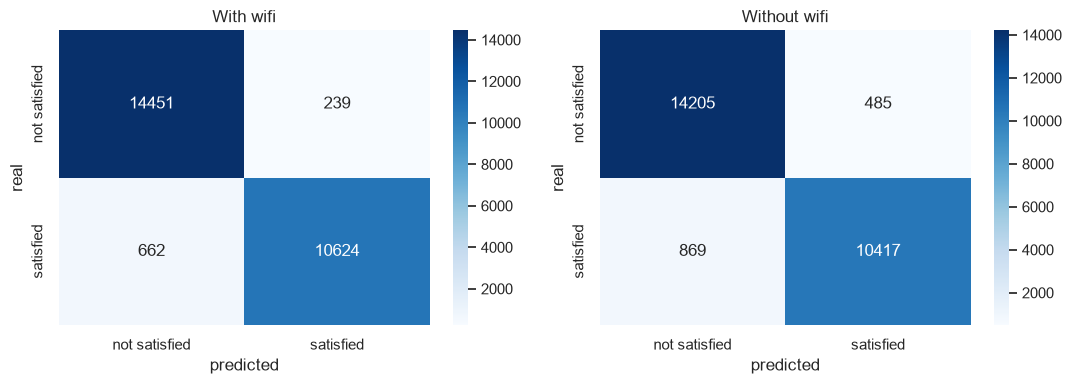

In [23]:
cm = confusion_matrix(y_test, pred)
cm_nw = confusion_matrix(y_test, pred_nw)

print("With wifi (rows = real, columns = predicted):")
print(cm)
print()
print("Without wifi:")
print(cm_nw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["not satisfied", "satisfied"], yticklabels=["not satisfied", "satisfied"])
axes[0].set_title("With wifi")

sns.heatmap(cm_nw, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["not satisfied", "satisfied"], yticklabels=["not satisfied", "satisfied"])
axes[1].set_title("Without wifi")

for ax in axes:
    ax.set_xlabel("predicted")
    ax.set_ylabel("real")

plt.tight_layout()
plt.savefig("../reports/figures/26_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

observation:

- Wrong calls: 239 + 662 = 901 of 25,976, which is 3.47%.
- Misses are the larger error. Of every 1,000 passengers who really were satisfied, the model misses about 59.
- False alarms are rare. Of every 1,000 it calls satisfied, about 22 are really not.

- Without wifi, there are 485 false alarms and 869 misses: 1,354 wrong calls, 5.21%. That's roughly 77 misses per 1,000 satisfied passengers and 44 false alarms per 1,000 "satisfied" calls.

#### ROC Curves

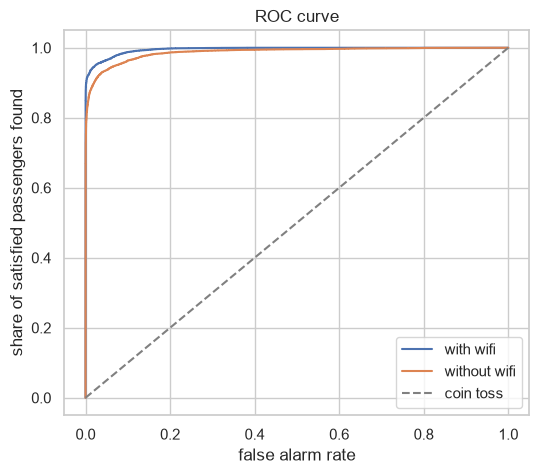

In [24]:
fpr, tpr, _ = roc_curve(y_test, chance)
fpr_nw, tpr_nw, _ = roc_curve(y_test, chance_nw)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="with wifi")
plt.plot(fpr_nw, tpr_nw, label="without wifi")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="coin toss")

plt.title("ROC curve")
plt.xlabel("false alarm rate")
plt.ylabel("share of satisfied passengers found")
plt.legend()
plt.savefig("../reports/figures/27_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

observation:

- two curves that shoot almost straight up the left side and then run along the top. That's what a very good model looks like. The blue curve (with wifi) sits slightly above the orange (without wifi). The grey dashed diagonal is a coin toss. The areas under the curves are the ROC-AUC scores: 99.54 and 98.71. For example, at a false-alarm rate of just a few percent, the with-wifi model already finds over 95% of satisfied passengers.


#### Precision-recall Curves

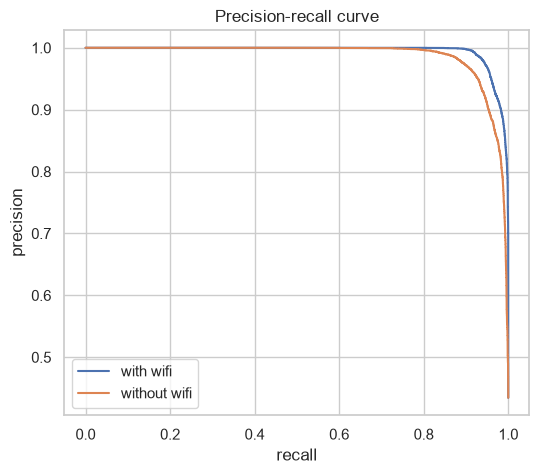

In [25]:
prec, rec, _ = precision_recall_curve(y_test, chance)
prec_nw, rec_nw, _ = precision_recall_curve(y_test, chance_nw)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label="with wifi")
plt.plot(rec_nw, prec_nw, label="without wifi")

plt.title("Precision-recall curve")
plt.xlabel("recall")
plt.ylabel("precision")
plt.legend()
plt.savefig("../reports/figures/28_precision_recall_curve.png", dpi=120, bbox_inches="tight")
plt.show()

observation :

- this precision stays close to 1.0 (nearly perfect) while recall climbs to about 0.85, then slides downwards, and falls off a cliff as recall nears 1.0. In words: the model can be nearly flawless if we accept missing some satisfied passengers, but if we insist on finding every last one, its false alarms pile up. The with-wifi curve stays above the without-wifi curve.

- We use the default cut-off of 0.5. A business could move it, for example to catch more satisfied passengers at the cost of more false alarms, and these curves show the price of doing so. We keep 0.5

#### Freature Importance

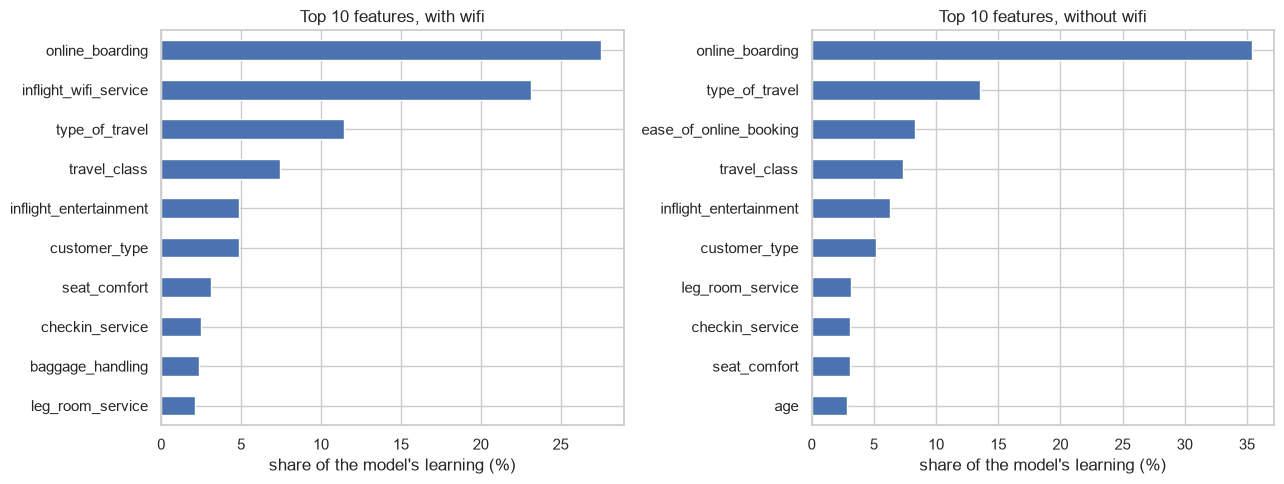

Top 5, with wifi:
online_boarding           27.6
inflight_wifi_service     23.2
type_of_travel            11.4
travel_class               7.5
inflight_entertainment     4.9
dtype: float64

Top 5, without wifi:
online_boarding           35.4
type_of_travel            13.6
ease_of_online_booking     8.3
travel_class               7.3
inflight_entertainment     6.3
dtype: float64


In [26]:
booster = final_model[-1].booster_
importance = pd.Series(booster.feature_importance(importance_type="gain"), index=booster.feature_name())
importance = importance / importance.sum() * 100

booster_nw = final_model_no_wifi[-1].booster_
importance_nw = pd.Series(booster_nw.feature_importance(importance_type="gain"), index=booster_nw.feature_name())
importance_nw = importance_nw / importance_nw.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

importance.sort_values().tail(10).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 features, with wifi")

importance_nw.sort_values().tail(10).plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 features, without wifi")

for ax in axes:
    ax.set_xlabel("share of the model's learning (%)")

plt.tight_layout()
plt.savefig("../reports/figures/29_final_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 5, with wifi:")
print(importance.sort_values(ascending=False).head(5).round(1))
print()
print("Top 5, without wifi:")
print(importance_nw.sort_values(ascending=False).head(5).round(1))

observation :
- Online boarding is the single most-used feature in both models (27.6% and 35.4%). That matches everything since Step 3: it had the highest correlation (0.50) and the biggest jump in the satisfaction charts.
- Wifi alone makes up 23.2% of the with-wifi model's learning. That is the suspicious wifi pattern from Steps 3 and 4 (scores 0 and 5 are about 99% satisfied).
- Without wifi, ease_of_online_booking jumps to 8.3%. It's 0.71 correlated with wifi (Step 4), so the model most likely uses it to recover part of what wifi told it. It doesn't fully replace it, because the without-wifi model is still 1.7 points less accurate.

#### who does the model get wrong

In [27]:
errors = X_test.copy()
errors["wrong"] = (pred != y_test)

print("Share wrong overall:", round(errors["wrong"].mean() * 100, 2), "%")
print()

for col in ["travel_class", "type_of_travel", "customer_type"]:
    table = errors.groupby(col)["wrong"].agg(["mean", "count"])
    table["mean"] = table["mean"] * 100
    table.columns = ["percent_wrong", "passengers"]
    print(table.round(2))
    print()

Share wrong overall: 3.47 %

              percent_wrong  passengers
travel_class                           
Business               2.31       12461
Economy                4.73       11697
Economy Plus           3.30        1818

                percent_wrong  passengers
type_of_travel                           
Business                 3.17       17968
Personal                 4.15        8008

               percent_wrong  passengers
customer_type                           
First-time              5.35        4673
Returning               3.06       21303



observation :

- the error rate is highest for Economy passengers (4.73%) and first-time customers (5.35%), and lowest for Business class (2.31%) and returning customers (3.06%). The gaps are noticeable, but no group is badly served: the worst is about 5 in 100 wrong. We don't know why, and the data can't tell us, so we won't guess.

#### checking is the model less sure about the passengers it gets wrong

In [28]:

errors["chance"] = chance
errors["sure"] = (errors["chance"] - 0.5).abs() * 2

print("Average confidence, passengers it got right:", round(errors.loc[~errors["wrong"], "sure"].mean() * 100, 1), "%")
print("Average confidence, passengers it got wrong:", round(errors.loc[errors["wrong"], "sure"].mean() * 100, 1), "%")

Average confidence, passengers it got right: 93.9 %
Average confidence, passengers it got wrong: 42.1 %


#### the success targets

In [29]:
targets = pd.DataFrame({
    "needed": [94, 93, 98],
    "with wifi": [test_scores.loc["accuracy", "with wifi"], test_scores.loc["f1", "with wifi"], test_scores.loc["roc_auc", "with wifi"]],
    "without wifi": [test_scores.loc["accuracy", "without wifi"], test_scores.loc["f1", "without wifi"], test_scores.loc["roc_auc", "without wifi"]],
}, index=["accuracy", "f1", "roc_auc"])

targets["with wifi met"] = targets["with wifi"] >= targets["needed"]
targets["without wifi met"] = targets["without wifi"] >= targets["needed"]

targets.round(2)

,needed,with wifi,without wifi,with wifi met,without wifi met
accuracy,94,96.53,94.79,True,True
f1,93,95.93,93.90,True,True
roc_auc,98,99.54,98.71,True,True


#### saving the final scores

In [30]:
test_scores.round(2).to_csv("../reports/final_test_results.csv")

print("Saved the final test scores")

Saved the final test scores


In [31]:
import os
import pickle
import datetime

import joblib
import sklearn
import lightgbm

model_folder = "../models/"

print("Models will be saved in:", os.path.abspath(model_folder))

Models will be saved in: d:\OMEN-16\ML-Projects\airline-satisfaction-ml\models


#### saving with joblib

In [32]:
joblib.dump(final_model, model_folder + "lightgbm_with_wifi.joblib")
joblib.dump(final_model_no_wifi, model_folder + "lightgbm_no_wifi.joblib")

print("Saved both models")

Saved both models


#### checking the saved file

In [36]:
for file_name in ["lightgbm_with_wifi.joblib", "lightgbm_no_wifi.joblib"]:
    size_mb = os.path.getsize(model_folder + file_name) / (1024 * 1024)
    print(file_name.ljust(28), round(size_mb, 2), "MB")

print()
print("GitHub's limit for one file is 100 MB")

lightgbm_with_wifi.joblib    1.98 MB
lightgbm_no_wifi.joblib      1.32 MB

GitHub's limit for one file is 100 MB


#### joblib Vs pickle

In [37]:
# the same model saved with pickle, only to compare
with open(model_folder + "demo.pkl", "wb") as file:
    pickle.dump(final_model_no_wifi, file)

pickle_mb = os.path.getsize(model_folder + "demo.pkl") / (1024 * 1024)
joblib_mb = os.path.getsize(model_folder + "lightgbm_no_wifi.joblib") / (1024 * 1024)

print("pickle:", round(pickle_mb, 2), "MB")
print("joblib:", round(joblib_mb, 2), "MB")

# we only need the joblib files, so remove the demo file again
os.remove(model_folder + "demo.pkl")
print("The demo file was deleted again")

pickle: 1.32 MB
joblib: 1.32 MB
The demo file was deleted again
